In [2]:
import pandas as pd
import matplotlib.pyplot as plt

round_df = pd.read_csv("/content/afl_plyer_rbr_st_raw.csv")
team_df = pd.read_csv("/content/team_matches_home_away_raw.csv.csv")

print("Round-by-Round shape:", round_df.shape)
print("Team Match shape:", team_df.shape)

Round-by-Round shape: (259685, 36)
Team Match shape: (15808, 19)


**Team names clean**

In [10]:
common_columns = round_df.columns.intersection(team_df.columns)

print("Common columns:")
print(list(common_columns))

Common columns:
['id', 'year', 'opponent', 'round', 'result', 'match_date', 'margin', 'team_key', 'round_key', 'date_key']


In [11]:
round_df["team_key"] = (
    round_df["team"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

team_df["team_key"] = (
    team_df["team_name"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

**Team name mismatch fix**

In [12]:
team_df["team_key"] = team_df["team_key"].replace({
    "W. Bulldogs": "Western Bulldogs"
})

**Round clean**

In [13]:
round_df["round_key"] = (
    round_df["round"]
    .astype(str)
    .str.strip()
)

team_df["round_key"] = (
    team_df["round"]
    .astype(str)
    .str.strip()
)

**Match date standardize**

In [14]:
round_df["date_key"] = pd.to_datetime(
    round_df["match_date"],
    errors="coerce"
).dt.strftime("%Y-%m-%d")

team_df["date_key"] = pd.to_datetime(
    team_df["match_date"],
    errors="coerce"
).dt.strftime("%Y-%m-%d")

**Context dataset**

In [15]:
context_df = team_df[
    [
        "team_key",
        "year",
        "round_key",
        "date_key",
        "home_away",
        "venue",
        "crowd"
    ]
].copy()

print(context_df.shape)

(15808, 7)


**duplicate key check**

In [16]:
duplicate_keys = context_df.duplicated(
    subset=[
        "team_key",
        "year",
        "round_key",
        "date_key"
    ]
).sum()

print("Duplicate composite keys:", duplicate_keys)

Duplicate composite keys: 0


**FINAL MERGE**

In [17]:
enriched_df = round_df.merge(
    context_df,
    on=[
        "team_key",
        "year",
        "round_key",
        "date_key"
    ],
    how="left",
    validate="many_to_one"
)

**Check enriched data**

In [18]:
enriched_df[
    [
        "team",
        "year",
        "round",
        "match_date",
        "home_away",
        "venue",
        "crowd",
        "fantasy_points"
    ]
].head(10)

,team,year,round,match_date,home_away,venue,crowd,fantasy_points
0,Hawthorn Hawks,1994,21,1994-08-14,A,Melbourne Cricket Ground,52562.0,36
1,Geelong Cats,2024,1,2024-03-16,H,GMHBA Stadium,39352.0,23
2,Essendon Bombers,1999,10,1999-06-04,A,AAMI Stadium,39389.0,67
3,Western Bulldogs,1994,21,1994-08-13,A,Waverley Park\r\n,14653.0,81
4,Richmond Tigers,1997,10,1997-05-31,H,Melbourne Cricket Ground,28879.0,32
5,St Kilda Saints,2002,2,2002-04-07,A,Domain Stadium,21138.0,0
6,Fremantle Dockers,2002,2,2002-04-07,H,Domain Stadium,21138.0,3
7,Brisbane Lions,2002,10,2002-06-01,A,AAMI Stadium,47279.0,20
8,Fremantle Dockers,1997,20,1997-08-16,A,Waverley Park,26201.0,36
9,Port Adelaide Power,1997,20,1997-08-16,A,The Gabba,20835.0,68


**TASK 3 MERGE VALIDATION**

Unmatched records

In [ ]:
validation_df = round_df.merge(
    context_df,
    on=[
        "team_key",
        "year",
        "round_key",
        "date_key"
    ],
    how="left",
    indicator=True
)

print(validation_df["_merge"].value_counts())

_merge
both          274089
left_only          0
right_only         0
Name: count, dtype: int64


Specifically unmatched records

In [ ]:
unmatched = validation_df[
    validation_df["_merge"] == "left_only"
]

print("Unmatched records:", len(unmatched))

Unmatched records: 0


**Rows before/after**

In [ ]:
print("Rows before merge:", len(round_df))
print("Rows after merge:", len(enriched_df))

if len(round_df) == len(enriched_df):
    print("PASS: Number of player records remained unchanged.")
else:
    print("WARNING: Number of records changed.")

Rows before merge: 274089
Rows after merge: 274089
PASS: Number of player records remained unchanged.


**Duplicates record**

In [ ]:
duplicates_before = round_df.duplicated().sum()
duplicates_after = enriched_df.duplicated().sum()

print("Duplicates before merge:", duplicates_before)
print("Duplicates after merge:", duplicates_after)

Duplicates before merge: 10
Duplicates after merge: 10


**Check added columns**

In [ ]:
print("Missing values in added columns:")

print(
    enriched_df[
        ["home_away", "venue", "crowd"]
    ].isna().sum()
)

Missing values in added columns:
home_away       0
venue           0
crowd        8955
dtype: int64


**TASK 4 CONTEXTUAL ANALYSIS**

Question 1: Home vs Away

In [ ]:
home_away_analysis = (
    enriched_df
    .groupby("home_away")["fantasy_points"]
    .agg(["count", "mean", "median"])
)

print(home_away_analysis)

            count       mean  median
home_away                           
A          137016  64.003386    63.0
H          137073  66.484472    65.0


**Home/Away graph**

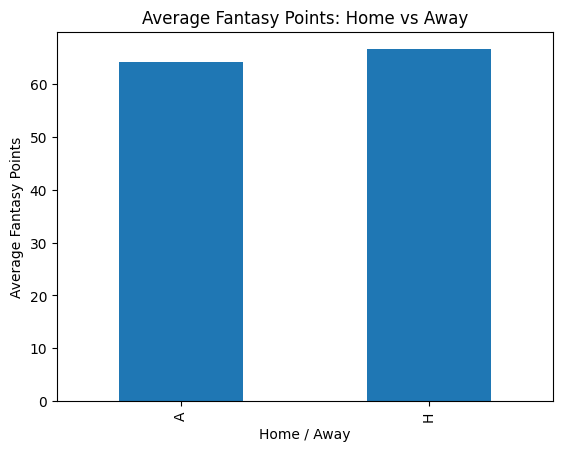

In [ ]:
home_away_analysis["mean"].plot(
    kind="bar",
    title="Average Fantasy Points: Home vs Away",
    xlabel="Home / Away",
    ylabel="Average Fantasy Points"
)

plt.show()

Question 2 — Crowd vs Fantasy Points

In [ ]:
crowd_correlation = (
    enriched_df[
        ["crowd", "fantasy_points"]
    ]
    .corr()
    .loc["crowd", "fantasy_points"]
)

print("Correlation:", crowd_correlation)

Correlation: 0.01289459378298295


**Crowd groups**

In [ ]:
crowd_df = enriched_df.dropna(
    subset=["crowd"]
).copy()

crowd_df["crowd_group"] = pd.qcut(
    crowd_df["crowd"],
    q=3,
    labels=[
        "Low Crowd",
        "Medium Crowd",
        "High Crowd"
    ]
)

print(crowd_df["crowd_group"].value_counts())

crowd_group
Low Crowd       88422
Medium Crowd    88371
High Crowd      88341
Name: count, dtype: int64


**Crowd performance**

In [ ]:
crowd_analysis = (
    crowd_df
    .groupby(
        "crowd_group",
        observed=True
    )["fantasy_points"]
    .agg(["count", "mean"])
)

print(crowd_analysis)

              count       mean
crowd_group                   
Low Crowd     88422  64.991778
Medium Crowd  88371  65.484763
High Crowd    88341  65.985216


**Crowd graph**

**Question 3 Venue Performance**

In [ ]:
venue_analysis = (
    enriched_df
    .groupby("venue")["fantasy_points"]
    .agg(["count", "mean"])
    .sort_values(
        "mean",
        ascending=False
    )
)

print(venue_analysis.head(10))

                   count       mean
venue                              
Junction Oval          3  75.333333
TIO Stadium\r\n      112  74.187500
Jiangwan Stadium     137  72.481752
UTAS Stadium\r\n     133  70.879699
Riverway Stadium      46  70.369565
Westpac Stadium      134  69.716418
TIO Traeger Park     494  69.615385
Accor Stadium\r\n     45  68.866667
Mars Stadium         639  68.040689
UTAS Stadium        4185  67.962007


**Reliable venue comparison**

In [ ]:
venue_100 = venue_analysis[
    venue_analysis["count"] >= 100
]

print(venue_100.head(10))

                  count       mean
venue                             
TIO Stadium\r\n     112  74.187500
Jiangwan Stadium    137  72.481752
UTAS Stadium\r\n    133  70.879699
Westpac Stadium     134  69.716418
TIO Traeger Park    494  69.615385
Mars Stadium        639  68.040689
UTAS Stadium       4185  67.962007
ENGIE Stadium      5010  67.852096
Marvel Stadium    50156  67.572354
Adelaide Oval     12836  67.563182


**Venue graph**

) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


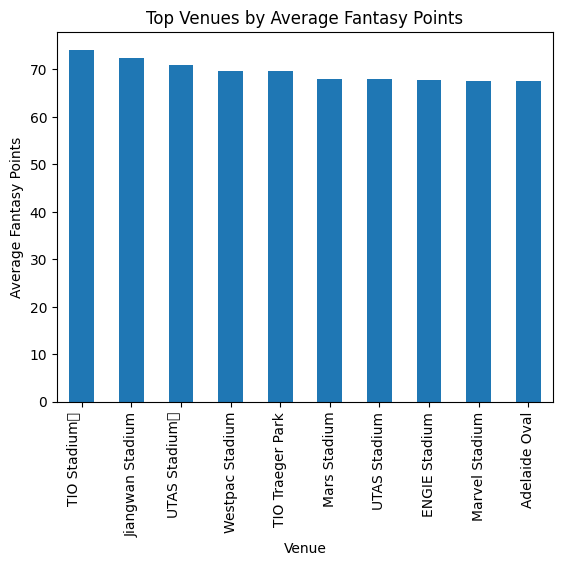

In [ ]:
venue_100.head(10)["mean"].plot(
    kind="bar",
    title="Top Venues by Average Fantasy Points",
    xlabel="Venue",
    ylabel="Average Fantasy Points"
)

plt.show()

# Week 2 Day 5 — Data Quality Report

## Merge Keys

The datasets were merged using the composite key:

- team
- year
- round
- match_date

The fields were standardized before merging by removing extra spaces, standardizing team names, cleaning round values, and converting match dates into a consistent format.

## Why a Composite Key Was Used

A single team name was not sufficient because each team appears in multiple matches.

The combination of team, year, round, and match date identifies the corresponding team-match record.

## Merge Strategy

A left merge was used because the Round-by-Round dataset is the main player-performance dataset. The purpose was to retain every player record while adding match context from the Team Match dataset.

The relationship was validated as many-to-one because the composite key was unique in the Team Match dataset.

## Context Enrichment

The following columns were added to the Round-by-Round dataset:

- home_away
- venue
- crowd

## Merge Validation

Player records before merge: 274,089

Player records after merge: 274,089

Unmatched records: 0

Therefore, all Round-by-Round player records were successfully matched with a Team Match context record.

## Duplicate Validation

Duplicate records before merge: 10

Duplicate records after merge: 10

Therefore, the merge did not introduce additional duplicate records. The 10 duplicate records were already present in the Round-by-Round dataset.

## Missing Context Values

Missing home/away values: 0

Missing venue values: 0

Missing crowd values: 8,955

The missing crowd values are treated as an existing data-quality issue in the source data rather than being artificially replaced during the integration.

## Data Quality Issues

- "W. Bulldogs" and "Western Bulldogs" were standardized to the same team name.
- Extra spaces in team names were removed.
- Round values were standardized.
- Match dates were converted into a consistent format.
- 8,955 crowd values are missing.
- 10 duplicate player records existed before the merge.

## Assumption

The combination of team, year, round, and match date uniquely identifies a team-match context record.

## Contextual Analysis

Home matches had an average of 66.48 fantasy points, while away matches had an average of 64.00 fantasy points.

The difference is 2.48 fantasy points. This is a descriptive difference and does not establish causation.

The correlation between crowd size and fantasy points was approximately 0.013, indicating a very weak linear relationship in this dataset.

Venue performance was compared using average fantasy points, while requiring at least 100 player records per venue to reduce the effect of very small samples.